In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully


In [ ]:
!pip install ultralytics -q

In [ ]:
import subprocess, os

result = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', '*.zip'],
    capture_output=True, text=True
)
print("Zip files found:")
print(result.stdout)

Zip files found:
/content/drive/MyDrive/AI_Interview_Communication_Analyzer.zip



In [ ]:
import zipfile, os

ZIP_PATH   = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer.zip'
EXTRACT_TO = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/'

print("Unzipping... this may take 2-5 minutes")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)
print("Unzip complete!")

Unzipping... this may take 2-5 minutes
Unzip complete!


In [ ]:
import os

BASE = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/DATASET'

checks = {
    'Train images': 'images/train',
    'Val images':   'images/val',
    'Train labels': 'labels/train',
    'Val labels':   'labels/val',
}

all_ok = True
for name, rel in checks.items():
    full  = os.path.join(BASE, rel)
    count = len(os.listdir(full)) if os.path.exists(full) else 0
    ok    = count > 0
    icon  = "OK" if ok else "EMPTY - check your zip"
    print(f"{name:15s} -> {count:5d} files  [{icon}]")
    if not ok:
        all_ok = False

print()
print("data.yaml exists:", os.path.exists(os.path.join(BASE, 'data.yaml')))
print()
print("Ready to train!" if all_ok else "Fix empty folders before training.")

Train images    ->     0 files  [EMPTY - check your zip]
Val images      ->     0 files  [EMPTY - check your zip]
Train labels    ->     0 files  [EMPTY - check your zip]
Val labels      ->     0 files  [EMPTY - check your zip]

data.yaml exists: True

Fix empty folders before training.


In [ ]:
import os

BASE = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer'

# Print full folder tree to find where images went
for root, dirs, files in os.walk(BASE):
    # Skip runs folder
    if 'runs' in root:
        continue
    level = root.replace(BASE, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        subindent = '  ' * (level + 1)
        # Show first 3 files as sample
        for f in files[:3]:
            print(f"{subindent}{f}")
        if len(files) > 3:
            print(f"{subindent}... and {len(files)-3} more files")

AI_Interview_Communication_Analyzer/
  video_to_img.py
  json2txt_fixed.py
  .gitignore
  ... and 5 more files
  final_dataset_unique/
    images/
      val/
      test/
      train/
    labels/
      val/
      test/
      train/
  .git/
    description
    config
    HEAD
    hooks/
      fsmonitor-watchman.sample
      pre-merge-commit.sample
      sendemail-validate.sample
      ... and 11 more files
    refs/
      tags/
      heads/
    objects/
      info/
      pack/
    info/
  inference_results/
  final_dataset/
    test/
      frame_000013.jpg
      frame_000066.txt
      frame_000077.jpg
      ... and 27 more files
    val/
      frame_000003.txt
      frame_000003.jpg
      frame_000028.txt
      ... and 17 more files
    train/
      frame_000099.jpg
      frame_000106.jpg
      frame_000011.jpg
      ... and 199 more files
  MLOPS-/
    .git/
      info/
      objects/
        82/
        72/
        db/
        info/
        pack/
        89/
      hooks/
      logs/
  

In [ ]:
import yaml

YAML_PATH = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET/data.yaml'

with open(YAML_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

print("Before:", cfg)

cfg['path']  = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET'
cfg['train'] = 'images/train'
cfg['val']   = 'images/val'

with open(YAML_PATH, 'w') as f:
    yaml.dump(cfg, f)

print("\nFixed! New config:")
with open(YAML_PATH, 'r') as f:
    print(f.read())

Before: {'path': 'E:/AI Interview & Communication Analyzer/DATASET', 'train': 'images/train', 'val': 'images/val', 'nc': 6, 'names': {0: 'Angry', 1: 'Discomfort', 2: 'Fear', 3: 'Happy', 4: 'Neutral', 5: 'Sad'}}

Fixed! New config:
names:
  0: Angry
  1: Discomfort
  2: Fear
  3: Happy
  4: Neutral
  5: Sad
nc: 6
path: /content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET
train: images/train
val: images/val



In [ ]:
import os

BASE = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET'

checks = {
    'Train images': 'images/train',
    'Val images':   'images/val',
    'Train labels': 'labels/train',
    'Val labels':   'labels/val',
}

for name, rel in checks.items():
    full  = os.path.join(BASE, rel)
    count = len(os.listdir(full)) if os.path.exists(full) else 0
    icon  = "OK" if count > 0 else "EMPTY"
    print(f"{name:15s} -> {count:5d} files  [{icon}]")

Train images    ->  6807 files  [OK]
Val images      ->  1725 files  [OK]
Train labels    ->  6807 files  [OK]
Val labels      ->  1725 files  [OK]


In [ ]:
import os

BASE = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET'

for cache in ['labels/train.cache', 'labels/val.cache']:
    path = os.path.join(BASE, cache)
    if os.path.exists(path):
        os.remove(path)
        print(f"Deleted: {cache}")
    else:
        print(f"Not found (ok): {cache}")

Deleted: labels/train.cache
Deleted: labels/val.cache


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics -q

In [ ]:
import torch.distributed as dist
import importlib

# Patch to prevent double kernel registration
try:
    import torch._C._distributed_c10d as _c10d
    import torch
    torch.ops._c10d_functional.__dict__.clear()
except:
    pass

print("Patch applied")

Patch applied


In [ ]:
!pip install ultralytics==8.3.0 -q
!pip install torch==2.4.0 torchvision==0.19.0 --index-url https://download.pytorch.org/whl/cu121 -q
print("Done — now go to Runtime → Restart session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 881.3/881.3 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 15.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requ

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics==8.3.0 -q
!pip install "torch==2.4.1" "torchvision==0.19.1" --index-url https://download.pytorch.org/whl/cu121 -q
print("Install done — NOW click Runtime → Restart session again before continuing")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 826.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 25.1 MB/s eta 0:00:00
Install done — NOW click Runtime → Restart session again before continuing


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import ultralytics
print("Torch version:       ", torch.__version__)        # must be 2.4.1
print("Ultralytics version: ", ultralytics.__version__)  # must be 8.3.0
print("GPU available:       ", torch.cuda.is_available())
print("Device:              ", torch.cuda.get_device_name(0))

WARNING ⚠️ Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch version:        2.4.1+cu121
Ultralytics version:  8.3.0
GPU available:        True
Device:               Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'
print("wandb disabled")

wandb disabled


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip uninstall wandb -y -q
print("wandb removed")

wandb removed


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE']     = 'disabled'

from ultralytics import YOLO

BASE = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer'

model = YOLO('yolov8n.pt')

model.train(
    data=f'{BASE}/DATASET/data.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    workers=0,
    exist_ok=True
    # ← project and name removed intentionally
    # results will save to runs/detect/train inside Colab
)

print("Training complete!")

New https://pypi.org/project/ultralytics/8.4.56 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=None, name=train, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_

train: Scanning /content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET/labels/train.cache... 6807 images, 413 backgrounds, 0 corrupt: 100%|██████████| 6807/6807 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET/labels/val.cache... 1725 images, 104 backgrounds, 0 corrupt: 100%|██████████| 1725/1725 [00:00<?, ?it/s]

Plotting labels to runs/detect/train/labels.jpg... 


...

      20/20      2.49G      0.164     0.1512     0.7932          7        640: 100%|██████████| 426/426 [03:48<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 54/54 [00:29<00:00,  1.81it/s]

                   all       1725       1621      0.996      0.989      0.995      0.989



20 epochs completed in 1.529 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.6MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.6MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 2,685,538 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 54/54 [00:31<00:00,  1.72it/s]


                   all       1725       1621      0.997      0.989      0.995       0.99
                 Angry        373        373      0.986      0.995      0.995      0.983
            Discomfort        217        217          1      0.984      0.995      0.987
                  Fear        293        293          1      0.972      0.995      0.993
                 Happy        187        187      0.998          1      0.995      0.993
               Neutral        281        281      0.996      0.993      0.994      0.994
                   Sad        270        270      0.999      0.989      0.995      0.987
Speed: 0.1ms preprocess, 1.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/train
Training complete!


In [ ]:
import shutil, os

BASE = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer'

# Save both best and last weights
shutil.copy('runs/detect/train/weights/best.pt',  f'{BASE}/best_emotion_model.pt')
shutil.copy('runs/detect/train/weights/last.pt',  f'{BASE}/last_emotion_model.pt')

# Save training results folder too
shutil.copytree('runs/detect/train', f'{BASE}/training_results', dirs_exist_ok=True)

print(f"best.pt size : {round(os.path.getsize(f'{BASE}/best_emotion_model.pt')/1024**2, 1)} MB")
print(f"last.pt size : {round(os.path.getsize(f'{BASE}/last_emotion_model.pt')/1024**2, 1)} MB")
print("All results saved to Drive!")

best.pt size : 5.3 MB
last.pt size : 5.3 MB
All results saved to Drive!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET/images/val/frame_000000_101458dd.jpg: 384x640 1 Neutral, 68.0ms
Speed: 11.5ms preprocess, 68.0ms inference, 36.6ms postprocess per image at shape (1, 3, 384, 640)


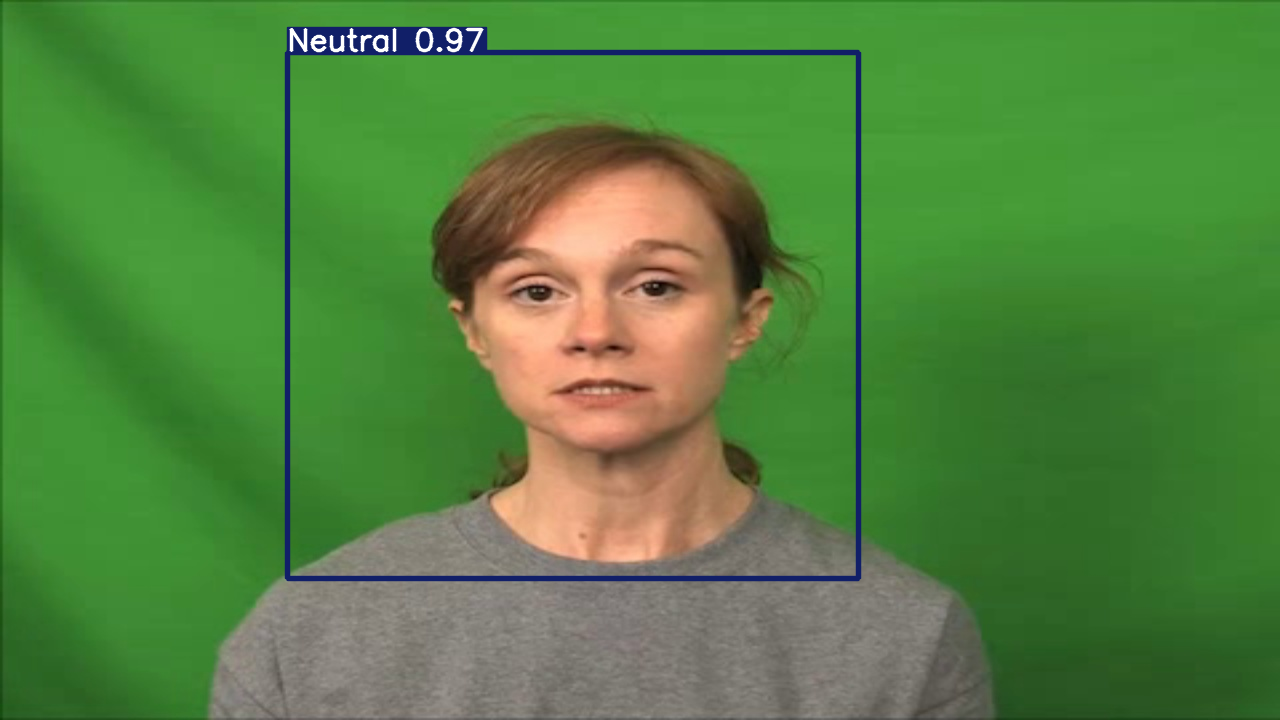

In [ ]:
import os
!pip install ultralytics -q
# Test your saved model on a new image
from ultralytics import YOLO

BASE = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer'

model = YOLO(f'{BASE}/best_emotion_model.pt')

results = model.predict(
    source='/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET/images/val/frame_000000_101458dd.jpg',
    conf=0.5
)
results[0].show()

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer'

model = YOLO(f'{BASE}/best_emotion_model.pt')

IMAGE = '/content/drive/MyDrive/download.jpeg'

# Try with very low confidence first to see anything
results = model.predict(
    source=IMAGE,
    conf=0.01,       # ← very low to catch any detection
    iou=0.3,
    save=True,
    verbose=True
)

# Show what was found
for r in results:
    print("Boxes found:", len(r.boxes))
    if len(r.boxes) > 0:
        for box in r.boxes:
            print(f"  Class: {model.names[int(box.cls)]}  Confidence: {round(float(box.conf)*100, 1)}%")
    else:
        print("Still no detections even at conf=0.01")


image 1/1 /content/drive/MyDrive/download.jpeg: 480x640 1 Happy, 9.6ms
Speed: 1.9ms preprocess, 9.6ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-3
Boxes found: 1
  Class: Happy  Confidence: 9.6%


In [ ]:
print(model.val())

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 0.1±0.0 MB/s, size: 106.4 KB)
val: Scanning /content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer/DATASET/labels/val.cache... 1725 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1725/1725 516.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 11.1s/it 19:58
                   all       1725       1621      0.997      0.989      0.995      0.987
                 Angry        373        373      0.986      0.995      0.995      0.979
            Discomfort        217        217          1      0.984      0.995      0.984
                  Fear        293        293          1      0.972      0.995      0.992
                 Happy        187        187      0.998          1      0.995      0.993
               Neutral        281      

In [ ]:
!pip install flask flask-cors ultralytics pyngrok

In [ ]:
# Step 1 — detect face with a general face detector
# Step 2 — crop the face
# Step 3 — run YOUR emotion model on the crop

from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

BASE   = '/content/drive/MyDrive/AI_Interview_Communication_Analyzer/AI_Interview_Communication_Analyzer'
face_model    = YOLO('yolov8n-face.pt')        # downloads automatically
emotion_model = YOLO(f'{BASE}/best_emotion_model.pt')

img = cv2.imread('/content/drive/MyDrive/download.jpeg')

# Detect faces
faces = face_model.predict(source=img, conf=0.3, verbose=False)[0].boxes

for i, box in enumerate(faces):
    x1,y1,x2,y2 = map(int, box.xyxy[0])
    crop = img[max(0,y1-20):y2+20, max(0,x1-20):x2+20]

    # Run emotion on crop
    result = emotion_model.predict(source=crop, conf=0.1, verbose=False)[0]
    if result.boxes:
        emo  = emotion_model.names[int(result.boxes[0].cls)]
        conf = round(float(result.boxes[0].conf)*100,1)
        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(img,f"{emo} {conf}%",(x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,0),2)

cv2_imshow(img)

ModuleNotFoundError: No module named 'ultralytics'